# Import Library

In [ ]:
pip install pandas networkx matplotlib python-louvain

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
import community as community_louvain

# Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/backup/kuliah/kuliah/sem 4/Analisis Sosial Media/FINAL PROJECT II/data.csv', encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# Data Preprocessing

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df = df.dropna(subset=["CustomerID"])
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(5225)

In [ ]:
df[df.duplicated()] # skip

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom


# Sampling

## 500 CustomerID unik

In [ ]:
df500 = df.copy()

In [ ]:
unique_customers = sorted(df500['CustomerID'].unique())[:500]
df500 = df500[df500['CustomerID'].isin(unique_customers)]
df500

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,12/1/2010 8:45,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## 500 data awal saja

In [ ]:
df500awal = df.copy()

In [ ]:
selected_rows = []
unique_customers = df500awal['CustomerID'].drop_duplicates() # agar bisa melihat konsumen lain, tidak hanya satu konsumen saja
total_rows = 0

for cust_id in unique_customers:
    cust_data = df500awal[df500awal['CustomerID'] == cust_id]
    if total_rows + len(cust_data) > 500:
        break
    selected_rows.append(cust_data)
    total_rows += len(cust_data)

# Gabungkan hasilnya
df500awal_sample_500 = pd.concat(selected_rows)
df500awal_sample_500

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
86898,C543611,82483,WOOD 2 DRAWER CABINET WHITE FINISH,-1,2/10/2011 14:38,4.95,17850.0,United Kingdom
86899,C543611,21874,GIN AND TONIC MUG,-1,2/10/2011 14:38,1.06,17850.0,United Kingdom
86900,C543611,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,-2,2/10/2011 14:38,2.75,17850.0,United Kingdom
86901,C543611,82483,WOOD 2 DRAWER CABINET WHITE FINISH,-1,2/10/2011 14:38,4.95,17850.0,United Kingdom


## 500 baris dari banyak customer

<details>
<summary>Penjelasan Sampling</summary>

- mengambil beberapa transaksi dari banyak customer  
- tidak mencapai 500 karena jika ditambahkan data lagi maka akan >500  
- sampling 500 agar visualisasi jelas dan tidak lag  

</details>

In [ ]:
df500unik = df.copy()

In [ ]:
df500unik = df500unik.sort_values(['CustomerID', 'InvoiceDate'])

unique_customers = df500unik['CustomerID'].drop_duplicates().sample(frac=1, random_state=42)

selected_rows = []
total_rows = 0

for cust_id in unique_customers:
    cust_data = df500unik[df500unik['CustomerID'] == cust_id]
    if total_rows + len(cust_data) > 500:
        break
    selected_rows.append(cust_data)
    total_rows += len(cust_data)

df500unik = pd.concat(selected_rows)
df500unik

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
74967,542538,22384,LUNCH BAG PINK POLKADOT,10,1/28/2011 13:54,1.65,15079.0,United Kingdom
74968,542538,22662,LUNCH BAG DOLLY GIRL DESIGN,10,1/28/2011 13:54,1.65,15079.0,United Kingdom
74969,542538,20725,LUNCH BAG RED RETROSPOT,10,1/28/2011 13:54,1.65,15079.0,United Kingdom
74970,542538,22383,LUNCH BAG SUKI DESIGN,10,1/28/2011 13:54,1.65,15079.0,United Kingdom
74971,542538,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,1/28/2011 13:54,0.85,15079.0,United Kingdom
...,...,...,...,...,...,...,...,...
222251,556413,22626,BLACK KITCHEN SCALES,1,6/10/2011 12:01,8.50,16005.0,United Kingdom
222252,556413,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,1,6/10/2011 12:01,2.95,16005.0,United Kingdom
222253,556413,22385,JUMBO BAG SPACEBOY DESIGN,1,6/10/2011 12:01,2.08,16005.0,United Kingdom
222254,556413,44092B,BLUE WHITE PLASTIC RINGS LAMPSHADE,3,6/10/2011 12:01,0.85,16005.0,United Kingdom


# Mapping

In [ ]:
desc_map_500 = df500.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
desc_map_500awal = df500awal.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
desc_map_500unik = df500unik.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
# untuk memtakan data, jadi drop dplicatesnya lalu melakuakn set index untuk stock code dan description

# Graph

In [ ]:
def build_graph(df):
    G = nx.Graph()
    for cust_id, group in df.groupby('CustomerID'):
        items = group['StockCode'].tolist()
        for item1, item2 in combinations(items, 2):
            if item1 == item2:
                continue
            if G.has_edge(item1, item2):
                G[item1][item2]['weight'] += 1
            else:
                G.add_edge(item1, item2, weight=1)
    return G

G500 = build_graph(df500)
G500awal = build_graph(df500awal)
G500unik = build_graph(df500unik)

# Community Detection

In [ ]:
def detect_and_export(df, desc_map, filename):
    G = build_graph(df)
    partition = community_louvain.best_partition(G)
    community_df = pd.DataFrame([
        {
            "StockCode": node,
            "Community": partition[node],
            "Description": desc_map.get(node, "Unknown")
        }
        for node in G.nodes
    ])
    community_df.to_csv(filename, index=False)
    return community_df, partition

In [ ]:
desc_map_500 = df500.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
desc_map_500awal = df500awal.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
desc_map_500unik = df500unik.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()

community_df_500, partition_500 = detect_and_export(df500, desc_map_500, "community_500.csv")
community_df_500awal, partition_500awal = detect_and_export(df500awal, desc_map_500awal, "community_500awal.csv")
community_df_500unik, partition_500unik = detect_and_export(df500unik, desc_map_500unik, "community_500unik.csv")

# Rekomendasi Produk

In [ ]:
def generate_recommendations(G, desc_map, filename):
    recommendations = {}
    for node in G.nodes:
        neighbors = G[node]
        top_neighbors = sorted(neighbors.items(), key=lambda x: x[1]['weight'], reverse=True)
        recommendations[node] = [
            desc_map.get(n[0], "Unknown") for n in top_neighbors[:5]
        ]

    # Konversi ke DataFrame
    reco_df = pd.DataFrame([
        {
            "StockCode": stock,
            "Description": desc_map.get(stock, "Unknown"),
            "Top1": recs[0] if len(recs) > 0 else "",
            "Top2": recs[1] if len(recs) > 1 else "",
            "Top3": recs[2] if len(recs) > 2 else "",
            "Top4": recs[3] if len(recs) > 3 else "",
            "Top5": recs[4] if len(recs) > 4 else "",
        }
        for stock, recs in recommendations.items()
    ])

    reco_df.to_csv(filename, index=False)
    return reco_df

In [ ]:
reco_500 = generate_recommendations(G500, desc_map_500, "reco_500.csv")
reco_500awal = generate_recommendations(G500awal, desc_map_500awal, "reco_500awal.csv")
reco_500unik = generate_recommendations(G500unik, desc_map_500unik, "reco_500unik.csv")

In [ ]:
def show_recommendation(item_code, reco_df):
    row = reco_df[reco_df["StockCode"] == item_code]
    if row.empty:
        print(f"Item dengan kode '{item_code}' tidak ditemukan.")
    else:
        print(f"\nRekomendasi untuk: {row['Description'].values[0]} (StockCode: {item_code})")
        for i in range(1, 6):
            top_item = row[f"Top{i}"].values[0]
            if top_item:
                print(f"Top {i}: {top_item}")

In [ ]:
show_recommendation("85123A", reco_500)
show_recommendation("85123A", reco_500awal)
show_recommendation("85123A", reco_500unik)


Rekomendasi untuk: WHITE HANGING HEART T-LIGHT HOLDER (StockCode: 85123A)
Top 1: REX CASH+CARRY JUMBO SHOPPER
Top 2: SMALL POPCORN HOLDER
Top 3: PARTY BUNTING
Top 4: Manual
Top 5: PAPER CHAIN KIT 50'S CHRISTMAS 

Rekomendasi untuk: WHITE HANGING HEART T-LIGHT HOLDER (StockCode: 85123A)
Top 1: REGENCY CAKESTAND 3 TIER
Top 2: JUMBO BAG RED RETROSPOT
Top 3: LUNCH BAG RED RETROSPOT
Top 4: SMALL POPCORN HOLDER
Top 5: WOODEN PICTURE FRAME WHITE FINISH

Rekomendasi untuk: WHITE HANGING HEART T-LIGHT HOLDER (StockCode: 85123A)
Top 1: PACK OF 20 NAPKINS PANTRY DESIGN
Top 2: REX CASH+CARRY JUMBO SHOPPER
Top 3: NATURAL SLATE RECTANGLE CHALKBOARD
Top 4: COFFEE MUG PEARS  DESIGN
Top 5: LUNCH BAG APPLE DESIGN


## Inputan StockCode

In [ ]:
def tampilkan_rekomendasi_dan_komunitas(stock_code, graph_dict, desc_map_dict, recom_df_dict, community_df_dict, partition_dict):
    print(f"\n[INFO] Menampilkan hasil untuk StockCode: {stock_code}\n")

    for metode in ["500", "500awal", "500unik"]:
        print("="*50)
        print(f"📦 Metode: {metode}")

        G = graph_dict.get(metode)
        desc_map = desc_map_dict.get(metode)
        reco_df = recom_df_dict.get(metode)
        community_df = community_df_dict.get(metode)
        partition = partition_dict.get(metode)

        if G is None or stock_code not in G.nodes:
            print("❌ StockCode tidak ditemukan dalam graf.")
            continue

        print(f"Produk: {desc_map.get(stock_code, 'Unknown')}")

        # Tampilkan 5 rekomendasi
        row = reco_df[reco_df["StockCode"] == stock_code]
        if not row.empty:
            print("\n🔁 Rekomendasi produk serupa:")
            for i in range(1, 6):
                rekom = row[f"Top{i}"].values[0]
                if rekom:
                    print(f"{i}. {rekom}")
        else:
            print("Tidak ada rekomendasi ditemukan.")

        # Tampilkan produk dalam komunitas yang sama
        com_id = partition.get(stock_code, None)
        if com_id is not None:
            produk_komunitas = community_df[
                (community_df["Community"] == com_id) & (community_df["StockCode"] != stock_code)
            ]["Description"].dropna().unique()[:5]

            print("\n👥 Produk lain dalam komunitas yang sama:")
            for i, item in enumerate(produk_komunitas, 1):
                print(f"{i}. {item}")
        else:
            print("Tidak ditemukan komunitas untuk produk ini.")

    print("="*50)

# --------------------
# PEMANGGILAN (contoh)
# --------------------

# Mapping semua graph, rekomendasi, komunitas, dan partition
graph_dict = {
    "500": G500,
    "500awal": G500awal,
    "500unik": G500unik
}
desc_map_dict = {
    "500": desc_map_500,
    "500awal": desc_map_500awal,
    "500unik": desc_map_500unik
}
recom_df_dict = {
    "500": reco_500,
    "500awal": reco_500awal,
    "500unik": reco_500unik
}
community_df_dict = {
    "500": community_df_500,
    "500awal": community_df_500awal,
    "500unik": community_df_500unik
}
partition_dict = {
    "500": partition_500,
    "500awal": partition_500awal,
    "500unik": partition_500unik
}

# Input interaktif
input_code = input("Masukkan StockCode produk: ").strip()
tampilkan_rekomendasi_dan_komunitas(
    input_code,
    graph_dict,
    desc_map_dict,
    recom_df_dict,
    community_df_dict,
    partition_dict
)

Masukkan StockCode produk: 85123A

[INFO] Menampilkan hasil untuk StockCode: 85123A

📦 Metode: 500
Produk: WHITE HANGING HEART T-LIGHT HOLDER

🔁 Rekomendasi produk serupa:
1. REX CASH+CARRY JUMBO SHOPPER
2. SMALL POPCORN HOLDER
3. PARTY BUNTING
4. Manual
5. PAPER CHAIN KIT 50'S CHRISTMAS 

👥 Produk lain dalam komunitas yang sama:
1. AIRLINE BAG VINTAGE JET SET BROWN
2. COLOUR GLASS. STAR T-LIGHT HOLDER
3. CLEAR DRAWER KNOB ACRYLIC EDWARDIAN
4. RED DRAWER KNOB ACRYLIC EDWARDIAN
5. PURPLE DRAWERKNOB ACRYLIC EDWARDIAN
📦 Metode: 500awal
Produk: WHITE HANGING HEART T-LIGHT HOLDER

🔁 Rekomendasi produk serupa:
1. REGENCY CAKESTAND 3 TIER
2. JUMBO BAG RED RETROSPOT
3. LUNCH BAG RED RETROSPOT
4. SMALL POPCORN HOLDER
5. WOODEN PICTURE FRAME WHITE FINISH

👥 Produk lain dalam komunitas yang sama:
1. BLACK CANDELABRA T-LIGHT HOLDER
2. MINI PAINT SET VINTAGE 
3. ALARM CLOCK BAKELIKE RED 
4. ALARM CLOCK BAKELIKE PINK
5. ALARM CLOCK BAKELIKE ORANGE
📦 Metode: 500unik
Produk: WHITE HANGING HEART T-LIGH

# Export Gephi

In [ ]:
nx.write_gexf(G500, "graph_community_500.gexf")
nx.write_gexf(G500awal, "graph_community_500awal.gexf")
nx.write_gexf(G500unik, "graph_community_500unik.gexf")

# Visualisasi Python

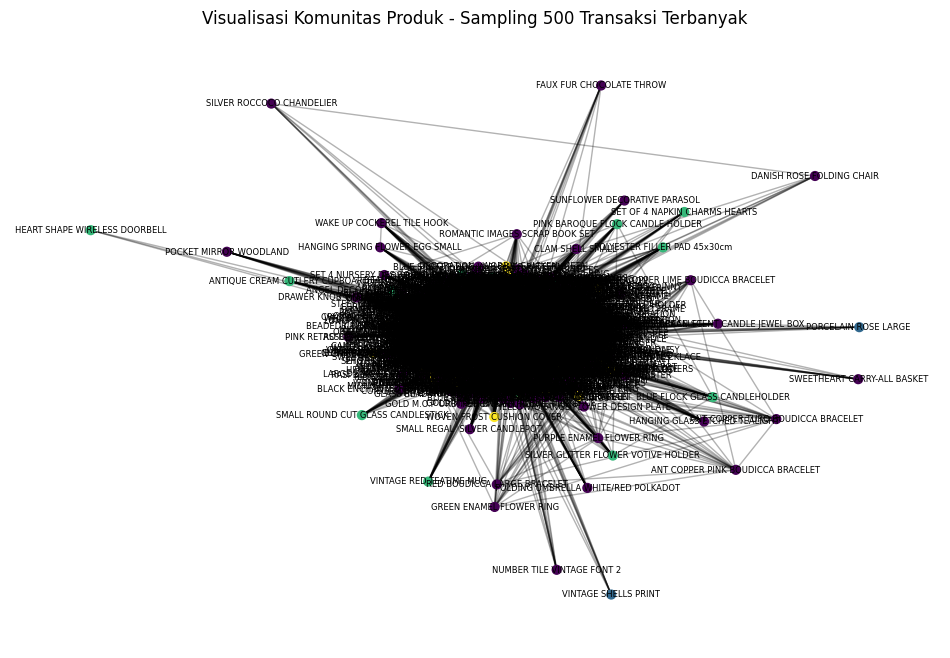

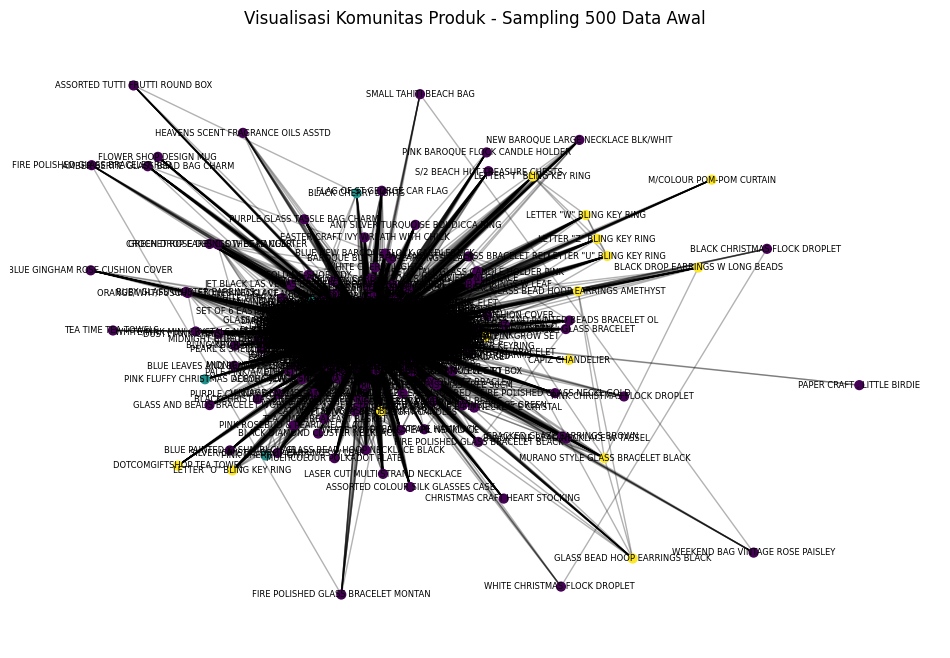

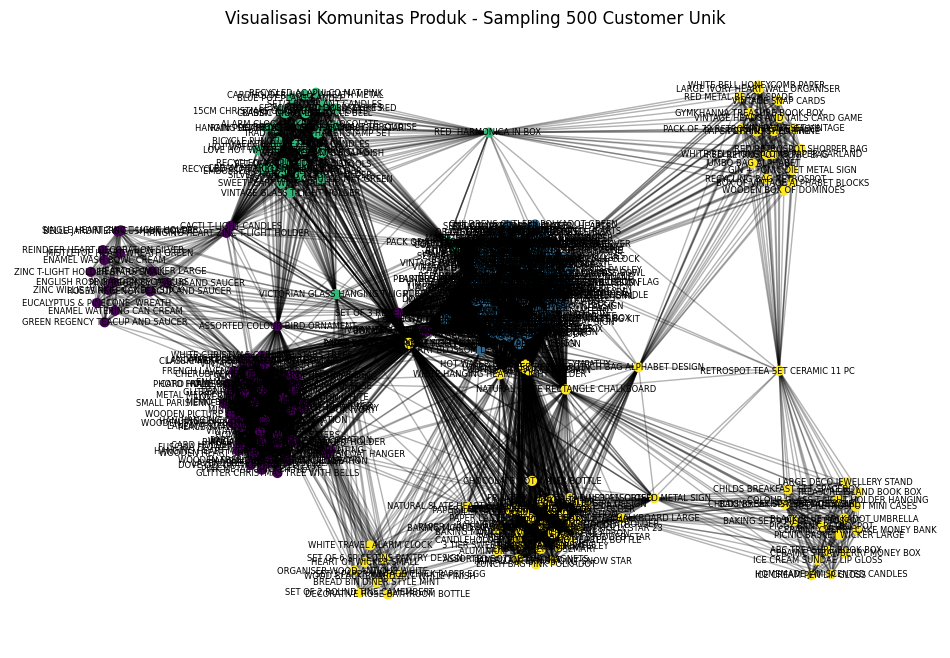

In [ ]:
def visualisasi_komunitas(G, partition, title, desc_map=None, show_label=False):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    colors = [partition[node] for node in G.nodes]
    cmap = plt.get_cmap('viridis', max(partition.values()) + 1)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=40, cmap=cmap)
    nx.draw_networkx_edges(G, pos, alpha=0.3)

    if show_label:
        if desc_map:
            labels = {n: desc_map.get(n, n) for n in G.nodes}
        else:
            labels = {n: n for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)

    plt.title(f"Visualisasi Komunitas Produk - {title}")
    plt.axis('off')
    plt.show()

visualisasi_komunitas(G500, partition_500, "Sampling 500 Transaksi Terbanyak", desc_map=desc_map_500, show_label=True)
visualisasi_komunitas(G500awal, partition_500awal, "Sampling 500 Data Awal", desc_map=desc_map_500awal, show_label=True)
visualisasi_komunitas(G500unik, partition_500unik, "Sampling 500 Customer Unik", desc_map=desc_map_500unik, show_label=True)

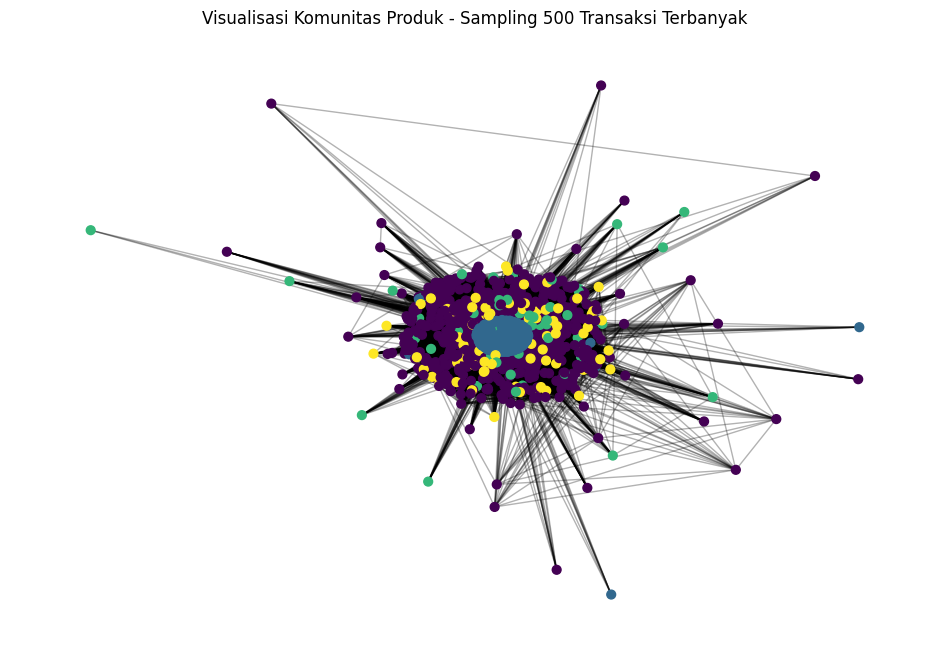

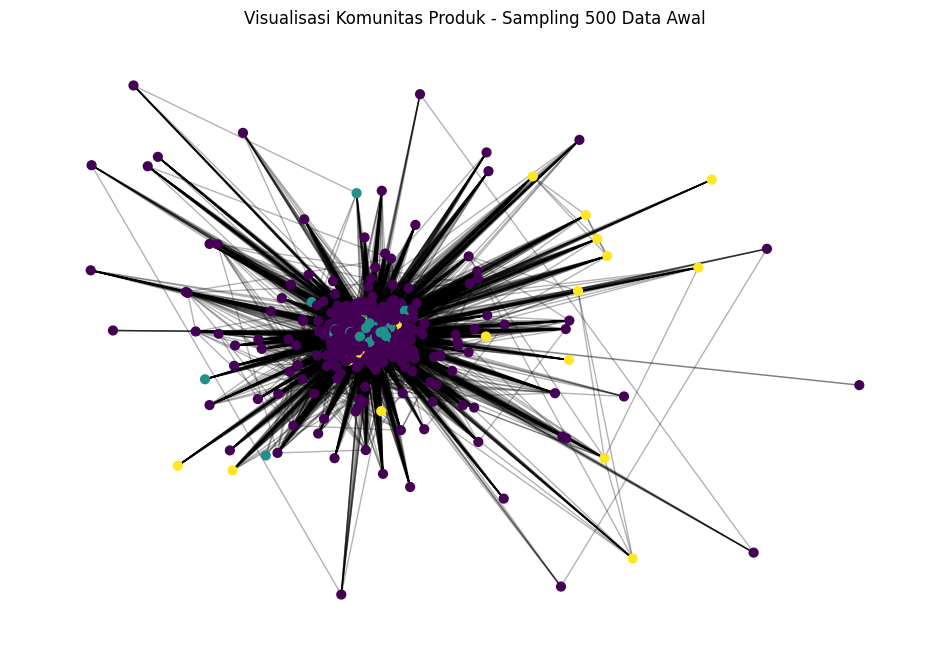

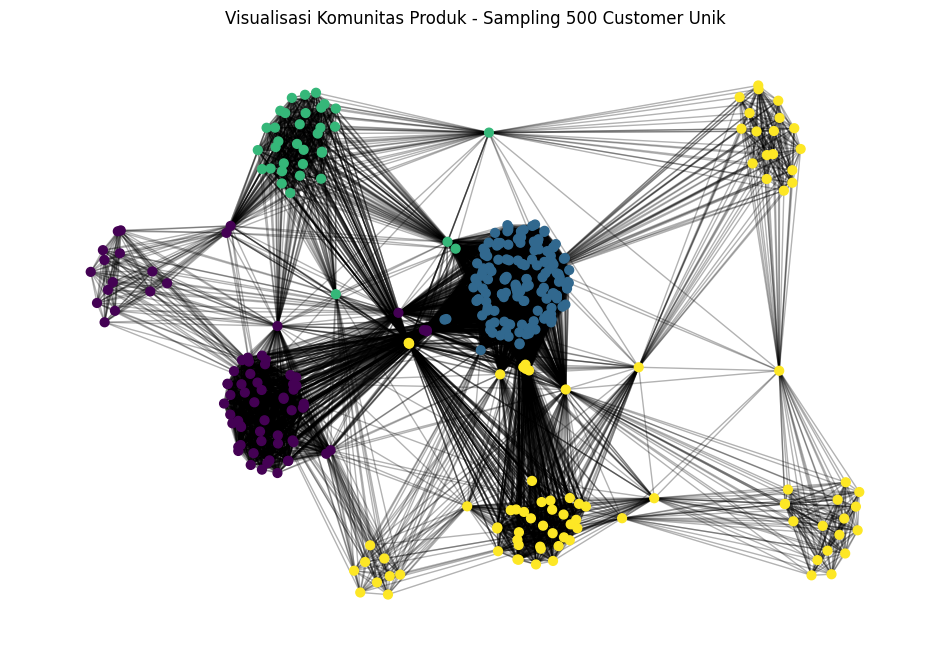

In [ ]:
visualisasi_komunitas(G500, partition_500, "Sampling 500 Transaksi Terbanyak")
visualisasi_komunitas(G500awal, partition_500awal, "Sampling 500 Data Awal")
visualisasi_komunitas(G500unik, partition_500unik, "Sampling 500 Customer Unik")

# Export Tabel Produk

In [ ]:
# Ekspor ke CSV
community_df_500.groupby("Community")["Description"].apply(list).reset_index() \
    .to_csv("produk_per_komunitas_500.csv", index=False)

community_df_500awal.groupby("Community")["Description"].apply(list).reset_index() \
    .to_csv("produk_per_komunitas_500awal.csv", index=False)

community_df_500unik.groupby("Community")["Description"].apply(list).reset_index() \
    .to_csv("produk_per_komunitas_500unik.csv", index=False)